# Synthetic Audio Benchmark: PyTorch DataLoader vs VVTKDataset + VVTKDataLoader

1. Generate **10 000** synthetic WAV files (16 kHz, mono, 5–30 s random-duration sine tones) + matching token sequences (`int16`, 10–400 length proportional to audio duration) → `wav/` and `tokens/`
2. Store both into a VVTK sharded binary dataset (`./data`) with FLAC compression for audio
3. Benchmark **2 epochs** of data loading — no training, just measure dataloader throughput
   - **Run A:** Standard PyTorch Dataset + DataLoader (reads `.wav` + `.npy` from disk, pads to 30 s / 400 tokens)
   - **Run B:** VVTKDataset + VVTKDataLoader (C++ ring-buffered loader with shuffle, same padding)

In [1]:
import torch
import numpy as np
import os, time
import soundfile as sf
from vvtk_dataset import VVTKDataset, VVTKDataLoader

## Step 1 — Generate synthetic WAV files and token sequences

In [ ]:
N = 10_000
SR = 16_000              # sample rate (Hz)
MIN_DUR, MAX_DUR = 5, 30 # duration range (seconds)
MIN_TOK, MAX_TOK = 10, 400
WAV_DIR = 'data/wav'
TOK_DIR = 'data/tokens'

os.makedirs(WAV_DIR, exist_ok=True)
os.makedirs(TOK_DIR, exist_ok=True)

rng = np.random.default_rng(42)

print(f'Generating {N} synthetic WAV files ({SR} Hz, {MIN_DUR}-{MAX_DUR}s) + token sequences ...')
t0 = time.time()

for i in range(N):
    dur = rng.uniform(MIN_DUR, MAX_DUR)
    n_samples = int(SR * dur)
    freq = rng.uniform(200, 4000)  # random tone frequency
    t = np.arange(n_samples, dtype=np.float32) / SR
    waveform = (0.5 * np.sin(2 * np.pi * freq * t)).astype(np.float32)

    # token length proportional to audio duration
    tok_len = int(MIN_TOK + (MAX_TOK - MIN_TOK) * (dur - MIN_DUR) / (MAX_DUR - MIN_DUR))
    tokens = rng.integers(0, 30000, size=tok_len, dtype=np.int16)

    sf.write(os.path.join(WAV_DIR, f'{i:05d}.wav'), waveform, SR)
    np.save(os.path.join(TOK_DIR, f'{i:05d}.npy'), tokens)

    if (i + 1) % 2_500 == 0:
        print(f'  {i+1}/{N} ({time.time()-t0:.1f}s)')

print(f'Done in {time.time()-t0:.1f}s')

Generating 10000 synthetic WAV files (16000 Hz, 5-30s) + token sequences ...
  2500/10000 (138.1s)
  5000/10000 (273.0s)
  7500/10000 (416.1s)
  10000/10000 (558.7s)
Done in 558.7s


## Step 2 — Store WAV + tokens into VVTK sharded binary dataset

In [ ]:
VVTK_PATH = 'data/shards/train'
NUM_SHARDS = 32

os.makedirs(os.path.dirname(VVTK_PATH), exist_ok=True)

print(f'Converting {N} WAV+tokens to VVTK shards (FLAC audio + raw tokens) ...')
t0 = time.time()

with VVTKDataset(VVTK_PATH, mode='wb', num_shards=NUM_SHARDS,
                 compression=['flac', 'none'],
                 compression_args=[{'sample_rate': SR}, {}]) as ds:
    for i in range(N):
        waveform, _ = sf.read(os.path.join(WAV_DIR, f'{i:05d}.wav'), dtype='float32')
        tokens = np.load(os.path.join(TOK_DIR, f'{i:05d}.npy'))
        ds.add(i, waveform, tokens)
        if (i + 1) % 2_500 == 0:
            print(f'  {i+1}/{N} ({time.time()-t0:.1f}s)')

print(f'Done in {time.time()-t0:.1f}s')

## Step 3 — Define WAV+Tokens Dataset class (pure PyTorch)

In [5]:
MAX_AUDIO_SAMPLES = SR * MAX_DUR   # 16000 * 30 = 480000
MAX_TOKEN_LEN = MAX_TOK            # 400

class WAVTokenDataset(torch.utils.data.Dataset):
    """Standard PyTorch Dataset that reads WAV + token .npy files from disk,
       pads audio to MAX_AUDIO_SAMPLES and tokens to MAX_TOKEN_LEN."""
    def __init__(self, wav_dir, tok_dir, n):
        self.wav_dir = wav_dir
        self.tok_dir = tok_dir
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        audio, _ = sf.read(os.path.join(self.wav_dir, f'{idx:05d}.wav'), dtype='float32')
        audio = torch.from_numpy(audio)
        audio_len = audio.shape[0]
        if audio_len < MAX_AUDIO_SAMPLES:
            audio = torch.nn.functional.pad(audio, (0, MAX_AUDIO_SAMPLES - audio_len))
        else:
            audio = audio[:MAX_AUDIO_SAMPLES]
            audio_len = MAX_AUDIO_SAMPLES

        tokens = torch.from_numpy(np.load(os.path.join(self.tok_dir, f'{idx:05d}.npy')).astype(np.int16))
        tok_len = tokens.shape[0]
        if tok_len < MAX_TOKEN_LEN:
            tokens = torch.nn.functional.pad(tokens, (0, MAX_TOKEN_LEN - tok_len))
        else:
            tokens = tokens[:MAX_TOKEN_LEN]
            tok_len = MAX_TOKEN_LEN

        return audio, torch.tensor(audio_len, dtype=torch.int64), tokens, torch.tensor(tok_len, dtype=torch.int64)

## Step 4 — Benchmark: PyTorch DataLoader with WAV+Tokens Dataset (2 epochs)

In [6]:
BATCH_SIZE = 64
NUM_WORKERS = 8
NUM_EPOCHS = 2

wav_ds = WAVTokenDataset(WAV_DIR, TOK_DIR, N)
wav_loader = torch.utils.data.DataLoader(
    wav_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS,
    pin_memory=True, persistent_workers=True
)

print(f'PyTorch WAV DataLoader: {len(wav_loader)} batches/epoch, batch_size={BATCH_SIZE}')
print(f'  Audio shape per sample: ({MAX_AUDIO_SAMPLES},) float32  |  Tokens shape: ({MAX_TOKEN_LEN},) int16')
print()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    batches = 0
    for audio, audio_len, tokens, tok_len in wav_loader:
        batches += 1
    elapsed = time.time() - t0
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({batches} batches, {N/elapsed:.0f} samples/s)')

PyTorch WAV DataLoader: 157 batches/epoch, batch_size=64
  Audio shape per sample: (480000,) float32  |  Tokens shape: (400,) int16

  Epoch 1: 50.59s  (157 batches, 198 samples/s)
  Epoch 2: 6.88s  (157 batches, 1454 samples/s)


## Step 5 — Benchmark: VVTKDataset + VVTKDataLoader with shuffle (2 epochs)

In [7]:
vvtk_ds = VVTKDataset(VVTK_PATH, mode='rb',
                      compression=['flac', 'none'],
                      compression_args=[{'sample_rate': SR}, {}])

vvtk_loader = VVTKDataLoader(
    vvtk_ds,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
    ring_size=4,
    shapes=[(MAX_AUDIO_SAMPLES,), (MAX_TOKEN_LEN,)],
    dtypes=[torch.float32, torch.int16],
    padding_values=[0.0, 0],
    shuffle=True
)

print(f'VVTKDataset + VVTKDataLoader: {len(vvtk_loader)} batches/epoch, batch_size={BATCH_SIZE}')
print(f'  Audio shape per sample: ({MAX_AUDIO_SAMPLES},) float32  |  Tokens shape: ({MAX_TOKEN_LEN},) int16')
print()

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    batches = 0
    for batch in vvtk_loader:
        batches += 1
    elapsed = time.time() - t0
    print(f'  Epoch {epoch}: {elapsed:.2f}s  ({batches} batches, {N/elapsed:.0f} samples/s)')

[VVTKLoader] Building index map...
[VVTKLoader] Ready in 0.01s
VVTKDataset + VVTKDataLoader: 157 batches/epoch, batch_size=64
  Audio shape per sample: (480000,) float32  |  Tokens shape: (400,) int16

  Epoch 1: 1.20s  (157 batches, 8308 samples/s)
  Epoch 2: 1.18s  (157 batches, 8508 samples/s)


Audio batch shape: torch.Size([64, 480000])  |  Tokens batch shape: torch.Size([64, 400])


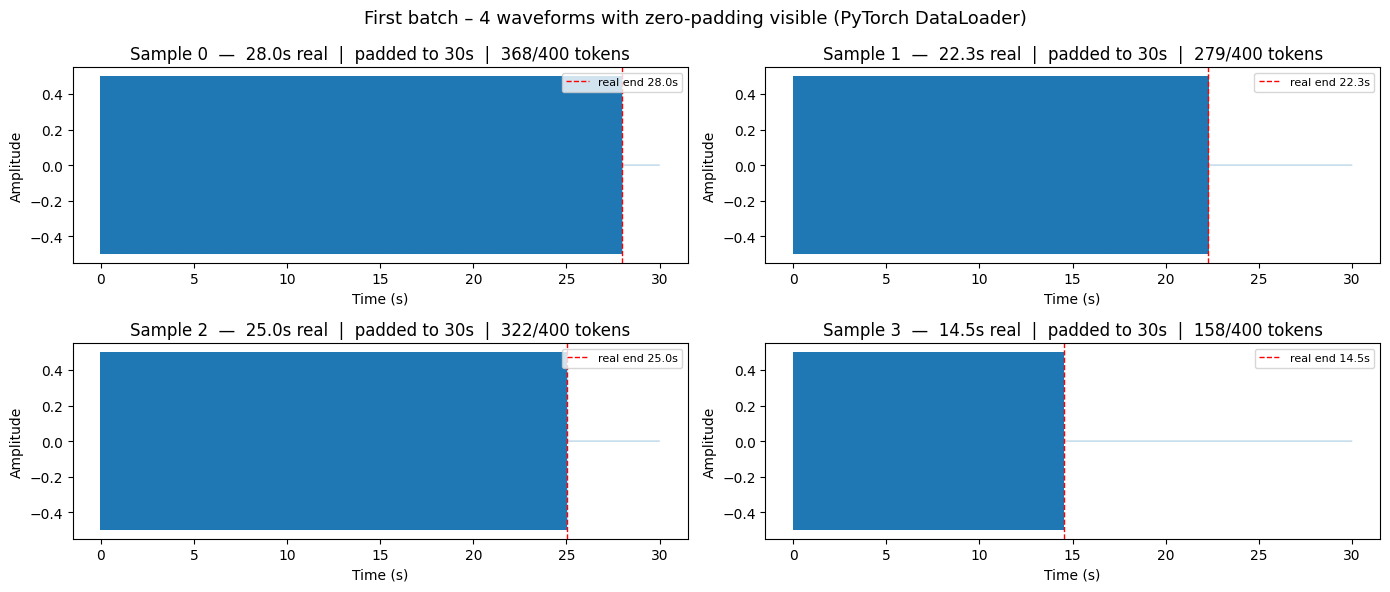

In [10]:
import matplotlib.pyplot as plt

# grab first batch from the PyTorch loader
batch_iter = iter(wav_loader)
audio_b, audio_len_b, tokens_b, tok_len_b = next(batch_iter)
print(f'Audio batch shape: {audio_b.shape}  |  Tokens batch shape: {tokens_b.shape}')

fig, axes = plt.subplots(2, 2, figsize=(14, 6))
for ax_idx, ax in enumerate(axes.flat):
    samples = audio_b[ax_idx].numpy()
    length = audio_len_b[ax_idx].item()
    t_full = np.arange(MAX_AUDIO_SAMPLES) / SR
    ax.plot(t_full, samples, linewidth=0.3, color='tab:blue')
    ax.axvline(x=length / SR, color='red', linestyle='--', linewidth=1, label=f'real end {length/SR:.1f}s')
    ax.set_title(f'Sample {ax_idx}  —  {length/SR:.1f}s real  |  padded to {MAX_AUDIO_SAMPLES/SR:.0f}s  |  {tok_len_b[ax_idx].item()}/{MAX_TOKEN_LEN} tokens')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Amplitude')
    ax.legend(loc='upper right', fontsize=8)
fig.suptitle('First batch – 4 waveforms with zero-padding visible (PyTorch DataLoader)', fontsize=13)
plt.tight_layout()
plt.show()